In [15]:
import numpy as np
from optic.models.devices import mzm, photodiode, edfa, iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel
from optic.models.channels import linearFiberChannel, ssfm
from optic.comm.modulation import modulateGray, grayMapping
from optic.comm.sources import bitSource, symbolSource
from optic.dsp.core import upsample, pulseShape, pnorm, anorm, signalPower, firFilter, decimate, symbolSync,phaseNoise

try:
    from optic.dsp.coreGPU import checkGPU
    if checkGPU():
        from optic.dsp.coreGPU import firFilter
    else:
        from optic.dsp.core import firFilter
except ImportError:
    from optic.dsp.core import firFilter

from optic.utils import parameters, dBm2W, ber2Qfactor
from optic.plot import eyediagram, pconst, plotPSD
import matplotlib.pyplot as plt
from scipy.special import erfc
from tqdm.notebook import tqdm
import scipy as sp
import scipy.constants as const

try:
    from optic.models.modelsGPU import manakovSSF
except:
    from optic.models.channels import manakovSSF

from optic.dsp.equalization import edc, mimoAdaptEqualizer, ffe
from optic.dsp.carrierRecovery import cpr
from optic.comm.metrics import fastBERcalc, monteCarloGMI, monteCarloMI, calcEVM, bert
from optic.dsp.clockRecovery import gardnerClockRecovery


import logging as logg
logg.basicConfig(level=logg.INFO, format='%(message)s', force=True)
import time

In [16]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

In [17]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Parameters Configuration of Optical System
# ---------------------------------------------------------------------------------------------------------------------------------------


# -----------------------------------------------
# Transmitter Parameters
#-------------------------------------------------

# 1) General Parameters
SpS = 16                 # samples per symbol
Rs = 32e9                # symbol rate [baud]
Fs = Rs * SpS            # sampling frequency [Hz]
M = 16                   # QPSK -> M=4, constType='qam'
nBits = 400000           # total bits to generate
rollOff = 0.01           # RRC roll-off
nFilterTaps = 1024       # RRC filter taps
mzmScale = 0.5           # IQM drive scale = "modulation depth" (0.5 is default in OptiCommPy)
Vpi =2                   # IQM pi Voltage  (2V is defualt in OpticommPy)
P_launch_dBm = 0         # desired launched optical power [dBm] -- for 4QAM try 6 dbm -- for 16QAM 0 was good
laserLinewidth = 100e3   # Hz (set e.g. 100e3 for phase noise), setting laserLineWidth to 0, models the ideal case 

# 2) Symbol Source Parameters
paramSymb = parameters()
paramSymb.nSymbols = int(nBits // np.log2(M))  # symbols = bits / log2(M)
paramSymb.M = M
paramSymb.constType = "qam"                    # 'qam' with M=4 -> QPSK
paramSymb.dist = "uniform"                     # uniform symbol probabilities
paramSymb.seed = 123
paramSymb.shapingFactor = 0

constSymb = grayMapping(paramSymb.M, paramSymb.constType)
if paramSymb.dist == "uniform":
   px = np.ones(paramSymb.M) / paramSymb.M
elif paramSymb.probDist == "maxwell-boltzmann":
   px = np.exp(-paramSymb.shapingFactor * np.abs(constSymb) ** 2)
   px = px / np.sum(px)
else:
   raise ValueError("Invalid probability distribution.")
paramSymb.px = px

# 3) UpSampling and FIR Parameters
paramPulse = parameters()
paramPulse.pulseType = "rrc"
paramPulse.nFilterTaps = nFilterTaps
paramPulse.rollOff = rollOff
paramPulse.SpS = SpS

# 4) IQM Parameters
paramIQM = parameters()
paramIQM.Vpi = Vpi
paramIQM.VbI = -Vpi
paramIQM.VbQ = -Vpi
paramIQM.Vphi = Vpi/2

# 5) Optical Carrier / LO field (Ein)
sigTx_length = paramSymb.nSymbols * SpS
if laserLinewidth and laserLinewidth > 0:
    phi_pn = phaseNoise(laserLinewidth, sigTx_length, 1 / Fs, seed=123)
    sigLO = np.exp(1j * phi_pn)
else:
    sigLO = np.ones_like(sigTx, dtype=complex)


# -----------------------------------------------
# Channel Parameters
#------------------------------------------------

# 1) Optical Channel Parameters
paramCh = parameters()
paramCh.Ltotal = 400       # total link distance [km]
paramCh.Lspan  = 80        # span length [km]
paramCh.alpha = 0.2        # fiber loss parameter [dB/km]
paramCh.D = 16             # fiber dispersion parameter [ps/nm/km]
paramCh.gamma = 1.3        # fiber nonlinear parameter [1/(W.km)]
paramCh.Fc = 193.1e12      # central optical frequency of the WDM spectrum
paramCh.hz = 0.5           # step-size of the split-step Fourier method [km]
paramCh.prgsBar = True     # show progress bar
paramCh.Fs = Rs*SpS        # sampling rate
paramCh.amp = 'edfa'       # type of amplifiers
paramCh.NF = 4.5           # Noise Figure of each amplirifer [dB]
#paramCh.seed = 456


# -----------------------------------------------
# Receiver Parameters
#------------------------------------------------

# 1) local oscillator (LO) parameters:
FO  = -128e6                 # frequency offset
paramLO = parameters()
paramLO.P =2              # power in dBm
paramLO.lw = 100e3          # laser linewidth
paramLO.RIN_var = 0
paramLO.Fs = Fs
paramLO.seed = 789 # random seed for noise generation
paramLO.freqShift = 0 + FO  # downshift of the channel to be demodulated add frequency offset

# 2) Front-End Parameters and photodiode paramters

# Frontend parameters
paramFE = parameters()
paramFE.Fs = Fs

# Photodiodes parameters
paramPD = parameters()
paramPD.B = Rs
paramPD.Fs = Fs
paramPD.ideal = True
paramPD.seed = 1011

# 3) Pulseshaping in the reciever using rrc filter

paramRxPulse = parameters()
paramRxPulse.SpS = SpS
paramRxPulse.nFilterTaps = nFilterTaps
paramRxPulse.rollOff = rollOff
paramRxPulse.pulseType = "rrc"

# 4) Decimation Parameters

paramDec = parameters()
paramDec.SpSin  = SpS
paramDec.SpSout = 2

# 5) Chromatic Dispersion Parameters

paramEDC = parameters()
paramEDC.L = paramCh.Ltotal
paramEDC.D = paramCh.D
paramEDC.Fc = paramCh.Fc
paramEDC.Rs = Rs
paramEDC.Fs = 2*Rs

# 6) Adaptive Equalization Parameters

paramEq = parameters()
paramEq.nTaps = 35
paramEq.SpS = paramDec.SpSout
paramEq.numIter = 2
paramEq.storeCoeff = False
paramEq.M = M
paramEq.shapingFactor = 0
paramEq.constType = "qam"
paramEq.prgsBar = False

if M == 4:
   paramEq.alg = ['cma','cma'] # QPSK
   paramEq.mu = [5e-3, 1e-3]
else:
   paramEq.alg = ['da-rde','rde'] # M-QAM
   paramEq.mu = [5e-3, 5e-4]

# 7) Carrier and Phase recovery parameters using bps

paramCPR = parameters()
paramCPR.alg = 'bps'
paramCPR.M   = M
paramCPR.constType ="qam"
paramCPR.shapingFactor = 0
paramCPR.N   = 25
paramCPR.B   = 64
paramCPR.returnPhases = True
paramCPR.Ts = 1/Rs

In [18]:
# ----------------------------------------------
# Simulation of the Optical System
# -----------------------------------------------

def simulate_optical_system(paramSymb, paramPulse,paramIQM,sigLO, paramCh, paramLO, paramFE, paramPD,paramRxPulse,paramDec
                            ,paramEDC,paramEq,paramCPR):

    """
   This function simulates the optical transmission of a single-polarization, 
   single-channel 16/4-QAM signal.

    Parameters
    ----------
    Uses Global Parameters defined above

    Returns
    -------
    y_CPR_1 : 
        Received signal at end of DSP chain (after CPR)
    symbTx: 
        Symbols Generated at Tx. Used in calculations.
    d:
        Noemlaized Symbol Synchronization with the SymbTx. Used in calculations.
    """

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # TRANSMITTER

    # 1) Generate Symbol Sequence
    symbTx = symbolSource(paramSymb)         

    # 2) Perform Upsampling + Pulse Shaping (RRC)
    pulse = pulseShape(paramPulse)           # create pulse
    symbolsUp = upsample(symbTx, SpS)        # shape: (nSymbols*SpS,)
    sigTx = firFilter(pulse, symbolsUp)      # pulse-shaped baseband waveform  

    sigTx = sigTx / np.max(np.abs(sigTx))    # normalize waveform to peak amplitude 1 (NOT RMS). This makes drive scaling predictable.
    
    # 3) IQ Modulation: Electrical -> Optical Domain Conversion
    u_drive = mzmScale * sigTx
    sigTxo = iqm(sigLO, u_drive, paramIQM)   # complex optical field at IQM output (still normalized power)

    # 4) Set Launched Optical Power
    P_launch_W = dBm2W(P_launch_dBm)
    sigTxo = np.sqrt(P_launch_W) * pnorm(sigTxo)

    # End of Transmitter
    # -----------------------------------------------------------------------------------------------------------------------------------------------------

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # CHANNEL

    sigCh = ssfm(sigTxo, paramCh)

    # End of CHANNEL
    # -----------------------------------------------------------------------------------------------------------------------------------------------------

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # RECEIVER

    # 1) Generate CW laser LO field
    # Parameter which might change so needs to be in the function
    paramLO.Ns = len(sigCh)
    sigLO_Rx = basicLaserModel(paramLO)

    # 2) Coherent Reciever for single-polarization.
    # Contains a 90 hybrid, two balanced photodiodes and iqmixing
    sigRxFrontEnd = coherentReceiver(sigCh, sigLO_Rx, paramFE, paramPD)

    # 3) Pusleshaping Function
    pulse = pulseShape(paramRxPulse) 
    sigRxPulseShape = firFilter(pulse, sigRxFrontEnd)

    # 4) Decimation
    sigRxDecimation = decimate(sigRxPulseShape, paramDec)

    # 5) Chromatic Dispersion Compensation for non-linear channel
    sigRxCD = edc(sigRxDecimation, paramEDC)

    # 6) Symbol Synchronization with the SymbTx
    symbRxCD = symbolSync(sigRxCD, symbTx, 2)

    # 7) Power Normalization
    x = pnorm(sigRxCD) 
    d = pnorm(symbRxCD)

    # 8) Adaptive Equalization Parameter which might change
    paramEq.L = [int(0.2*d.shape[0]), int(0.8*d.shape[0])]
    y_EQ = mimoAdaptEqualizer(x, paramEq, d)

    # 9) Carrier and Phase recovery using bps in the parameters
    y_CPR_1, θ = cpr(y_EQ, paramCPR)

    return y_CPR_1, symbTx,d
    # End of RECEIVER
    # -----------------------------------------------------------------------------------------------------------------------------------------------------

# Running the function to check that it works
y_CPR_1, symbTx, d= simulate_optical_system(paramSymb, paramPulse,paramIQM,sigLO, paramCh, paramLO, paramFE, paramPD,paramRxPulse,paramDec
                            ,paramEDC,paramEq,paramCPR )








  0%|          | 0/5 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 224 taps, FFT size: 256
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.020253.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.015469.
rde - training stage #1
rde MSE = 0.012133.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...
Estimated linewidth: 374.399 kHz


 SER: 1.111e-05,  
 BER: 2.778e-06   
 SNR: 22.071 dB
 EVM: 0.623 %
 Qfactor: 6.573,  


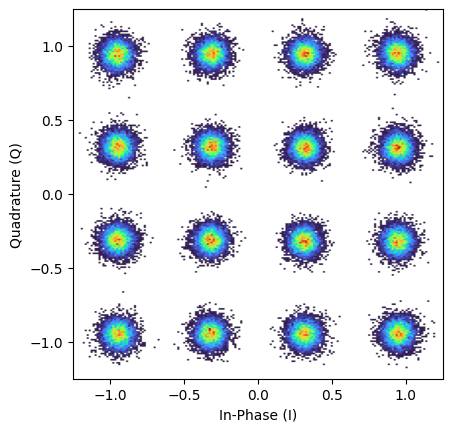

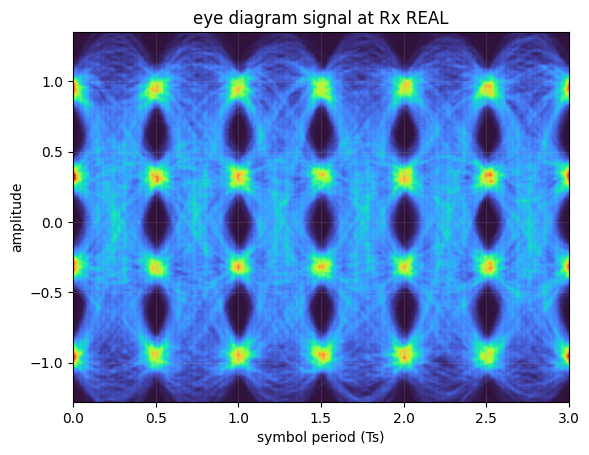

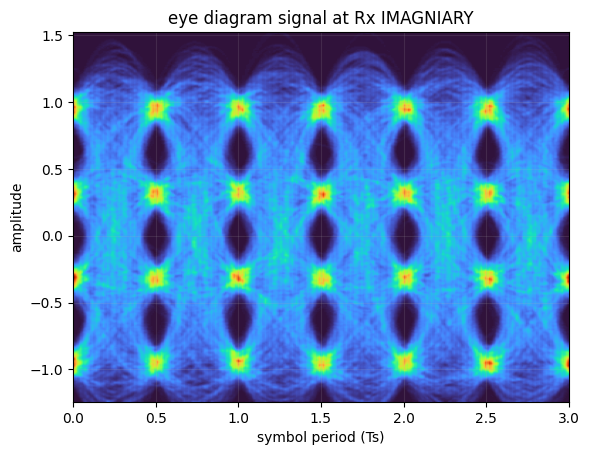

In [19]:
"""Performance Metric Exploration for Single Polarization
"""

# remove phase ambiguity for 4-QAM/QPSK
if M == 16:
    discard = 5000
    ind = np.arange(discard, len(symbTx) - discard)

   # now compute metrics (both are 1 sample/symbol and same length)
    BER, SER, SNR = fastBERcalc(y_CPR_1[ind], d[ind], M, 'qam', px = paramSymb.px)
    EVM = calcEVM(y_CPR_1[ind], M, 'qam', d[ind])
    Qfactor = ber2Qfactor(BER[0])

    print(' SER: %.3e,  '%(SER[0]))
    print(' BER: %.3e   '%(BER[0]))
    print(' SNR: %.3f dB'%(SNR[0]))
    print(' EVM: %.3f %%'%(EVM[0]*100))
    print(' Qfactor: %.3f,  '%(Qfactor))

elif M == 4:
    # 1) Normalize
    y = pnorm(y_CPR_1).squeeze()
    d = pnorm(symbTx).squeeze()

    # 2) Find best integer symbol shift via correlation on a window
    L = min(200000, len(y), len(d))
    y0 = y[:L]
    d0 = d[:L]

    Nfft = 1 << int(np.ceil(np.log2(2*L)))
    corr = np.fft.ifft(np.fft.fft(y0, Nfft) * np.conj(np.fft.fft(d0, Nfft)))
    k = int(np.argmax(np.abs(corr)))
    if k > Nfft//2:
        k -= Nfft
    print("estimated shift k =", k)

    # 3) Apply the shift to align y and d
    if k >= 0:
        y_al = y[k:]
        d_al = d[:len(y_al)]
    else:
        d_al = d[-k:]
        y_al = y[:len(d_al)]

    N = min(len(y_al), len(d_al))
    y_al = y_al[:N]
    d_al = d_al[:N]

    # 4) Now do constant complex rotation on ALIGNED sequences
    discard = 5000
    discard = min(discard, N//4)
    ind = np.arange(discard, N-discard)

    rot = np.mean(d_al[ind] / y_al[ind])
    y_corr = pnorm(rot * y_al)

    # 5) Metrics
    BER, SER, SNR = fastBERcalc(y_corr[ind], d_al[ind], M, 'qam', px=paramSymb.px)
    EVM = calcEVM(y_corr[ind], M, 'qam', d_al[ind])
    Qfactor = ber2Qfactor(BER[0])

    print("SER:", SER[0], "BER:", BER[0], "SNR:", SNR[0])
    print(' EVM: %.3f %%'%(EVM[0]*100))
    print(' Qfactor: %.3f,  '%(Qfactor))

discard = 5000
# plot constellations
pconst(y_CPR_1[discard:-discard])

# plotting eye diagrams of sigTx
eyediagram(y_CPR_1.real[discard:-discard], y_CPR_1.real.size-2*discard, paramDec.SpSout, plotlabel='signal at Rx REAL', ptype='fancy')
eyediagram(y_CPR_1.imag[discard:-discard], y_CPR_1.imag.size-2*discard, paramDec.SpSout, plotlabel='signal at Rx IMAGNIARY', ptype='fancy')

